In [87]:
import os
import pandas as pd
from openai import OpenAI

import numpy as np
import json
from dotenv import load_dotenv

In [88]:
repo_dir = "/Users/haya1/Documents/LanguageModel_Labels/congressional_bills"
os.chdir(repo_dir)

# Place API_KEY in the .env file
load_dotenv()
api_key = os.environ.get('API_KEY')
client = OpenAI(api_key=api_key)

## Generate prompts

In [89]:
data_dir = os.path.join(repo_dir, "01_bills")
bills = pd.read_csv(os.path.join(data_dir, "bills.csv"))[['BillID', 'Major', 'MajorText', 'Description']]

llm_dir = os.path.join(repo_dir, "02_llm")
# base_prompt = open(os.path.join(llm_dir, "base_prompt_json.txt"), 'r').read()

In [98]:
MAJOR_TEXT = {}
CATEGORIES = ""
for major in bills["Major"].unique(): 
    dict_key = int(major)
    dict_val = bills.loc[bills["Major"]==major, "MajorText"].unique()[0]
    MAJOR_TEXT[dict_key] = dict_val
    CATEGORIES += "%d. %s\n" % (dict_key, dict_val)

In [130]:
prompting_strategies = pd.DataFrame(data={
    "Name": [
        "No Modification", 
        "Persona Modification", "Persona Modification", "Persona Modification", "Persona Modification", 
        "Chain-of-Thoughts Prompting", "Chain-of-Thoughts Prompting", "Chain-of-Thoughts Prompting", 
        "Few-Shot Prompting", "Few-Shot Prompting", "Few-Shot Prompting"
        ],
    "BeforeQuestion": [
        "",
        "You are a knowledgeable political analyst. ",
        "Answer this question as if you are a political scientist that studies legislation in the United States Congress. ",
        "Answer this question as if you are an expert in United States politics. ",
        "Answer this question as if you were a helpful research assistant for a political scientist. ",
        "", "", "",
        "", "", "",
        ],
    "BeforeAnswer": [
        "", 
        "", "", "", "", 
        "Think carefully. ", 
        "Let's think step by step. Lay out each step. ", 
        "Please provide an explanation for your answer. ",
        "", "", "",
    ],
    "Explanation":[
        "", 
        "", "", "", "",
        ',\n    "Explanation": a one-sentence explanation of your bill category answer',
        ',\n    "Explanation": a one-sentence explanation of your bill category answer',
        ',\n    "Explanation": a one-sentence explanation of your bill category answer',
        "", "", "",
    ],
    "Examples":[
        np.nan, 
        np.nan, np.nan, np.nan,  np.nan,
        np.nan, np.nan, np.nan, 
        1, 2, 3,
    ],
    "Model":[
        "gpt-3.5-turbo",
        "gpt-3.5-turbo", "gpt-3.5-turbo", "gpt-3.5-turbo", "gpt-3.5-turbo", 
        "gpt-3.5-turbo", "gpt-3.5-turbo", "gpt-3.5-turbo", 
        "gpt-3.5-turbo", "gpt-3.5-turbo", "gpt-3.5-turbo", 
    ]
})

prompting_strategies.insert(loc=0, column="StrategyID", value = list(range(1, len(prompting_strategies)+1)))
prompting_strategies

,StrategyID,Name,BeforeQuestion,BeforeAnswer,Explanation,Examples,Model
0,1,No Modification,,,,NaN,gpt-3.5-turbo
1,2,Persona Modification,You are a knowledgeable political analyst.,,,NaN,gpt-3.5-turbo
2,3,Persona Modification,Answer this question as if you are a political...,,,NaN,gpt-3.5-turbo
3,4,Persona Modification,Answer this question as if you are an expert i...,,,NaN,gpt-3.5-turbo
4,5,Persona Modification,Answer this question as if you were a helpful ...,,,NaN,gpt-3.5-turbo
5,6,Chain-of-Thoughts Prompting,,Think carefully.,",\n ""Explanation"": a one-sentence explanati...",NaN,gpt-3.5-turbo
6,7,Chain-of-Thoughts Prompting,,Let's think step by step. Lay out each step.,",\n ""Explanation"": a one-sentence explanati...",NaN,gpt-3.5-turbo
7,8,Chain-of-Thoughts Prompting,,Please provide an explanation for your answer.,",\n ""Explanation"": a one-sentence explanati...",NaN,gpt-3.5-turbo
8,9,Few-Shot Prompting,,,,1.0,gpt-3.5-turbo
9,10,Few-Shot Prompting,,,,2.0,gpt-3.5-turbo


In [93]:
def create_message_user(description, before_question=None, before_answer=None, answer_format_explanation=None):
    base_prompt = open(os.path.join(repo_dir, "02_llm/base_prompt_json.txt"), 'r').read()
    before_question = "" if before_question is None else before_question
    before_answer = "" if before_answer is None else before_answer
    answer_format_explanation = "" if answer_format_explanation is None else answer_format_explanation

    content =  base_prompt % (before_question, description, CATEGORIES, before_answer, answer_format_explanation)
    return {"role": "user", "content": content}
print(create_message_user(description="A bill description.")["content"])

def create_message_assistant(category, confidence, explanation=None):
    base_answer = {
        "Category": category,
        "Confidence": np.round(confidence, decimals=2)
    }

    if explanation is not None:
        base_answer["explanation"] = explanation

    prompt =  json.dumps(base_answer)
    return {"role": "assistant", "content": prompt}

def create_fewshot_examples(bills_examples_set, min_confidence=0.8, max_confidence=1):
    messages = []
    for _, bill in bills_examples_set.iterrows():
        messages.append(create_message_user(description=bill["Description"]))
        messages.append(create_message_assistant(category=bill["Major"], confidence=np.random.uniform(min_confidence, max_confidence)))
    return messages

Here is a description of a bill introduced in the U.S. Congress:
"A bill description."

Please classify this description into one of the following categories:
1. Macroeconomics
2. Civil Rights, Minority Issues, and Civil Liberties
3. Health
4. Agriculture
5. Labor and Employment
6. Education
7. Environment
8. Energy
9. Immigration
10. Transportation
11. Law, Crime, and Family Issues
12. Social Welfare
13. Community Development and Housing Issues
14. Banking, Finance, and Domestic Commerce
15. Defense
16. Space, Science, Technology, and Communications
17. Foreign Trade
18. International Affairs and Foreign Aid
19. Government Operations
20. Public Lands and Water Management

Output a JSON object structured like: {
    "Category": an integer from 1 to 21 of the bill category,
    "Confidence": a number from 0 to 1 with 2 decimal places of your confidence in your bill classification
}


In [94]:
# Bills used for few-shot prompting
bills_examples_path = os.path.join(llm_dir, "bills_examples.csv")
if os.path.exists(bills_examples_path):
    bills_examples = pd.read_csv(bills_examples_path)
else:
    # TODO: add seed for replication
    bills_examples = bills.groupby("Major").sample(n=1, replace=False).sample(n=15, replace=False).reset_index(drop=True)
    bills_examples["ExampleSet"] = [1,2,3] * 5
    bills_examples.to_csv(os.path.join(llm_dir, "bills_examples.csv"), index=False)

condition = bills["BillID"].apply(lambda x: x not in bills_examples["BillID"].to_list())
bills_without_examples = bills[condition]
print(f"Excluded few-shot examples, n = {len(bills_examples)}, from the data. Number of remaining bills = {len(bills_without_examples)}")


Excluded few-shot examples, n = 15, from the data. Number of remaining bills = 240445


In [84]:
bills_without_examples = bills_without_examples.groupby('Major').sample(n=5) # .sample(n=100) # TODO: remove .groupby('Major').sample(n=2).sample(n=5)
print(f"Currently we test the code on only {len(bills_without_examples)} bills")
bills_without_examples.to_csv(os.path.join(llm_dir, "bills_without_examples.csv"), index=False)

Currently we test the code on only 100 bills


In [74]:
# TODO: improve prompt creation

# # def save_examples(josnl_path, examples):
# bills_examples = pd.read_csv(os.path.join(llm_dir, "bills_examples.csv"))

# prompts = []
# for _, strategy in prompting_strategies.iterrows():
#     example_set = bills_examples[bills_examples["ExampleSet"] == strategy["ExampleSet"]]
#     message = [] if (strategy["Name"]!="Few-Shot Prompting") else create_fewshot_examples(example_set)
#     prompts.append({"Example": message})

# prompts_path = os.path.join(llm_dir, "examples01.jsonl")
# with open(prompts_path, "w") as f:
#     for prompt in prompts:
#         f.write(json.dumps(prompt) + "\n")

In [131]:
examples = pd.read_csv(os.path.join(llm_dir, "bills_examples.csv"))
bills = pd.read_csv(os.path.join(llm_dir, "bills_without_examples.csv"))

# n_prompts = len(bills) * len(prompting_strategies)
# prompt_id = list(range(1, n_prompts+1))
prompt_id = 0
prompts = []

for _, bill in bills.iterrows():
    for _, strategy in prompting_strategies.iterrows():
        
        example_set = examples[examples["ExampleSet"]== strategy["Examples"]]
        messages = [] if (strategy["Name"]!="Few-Shot Prompting") else create_fewshot_examples(example_set)
        messages.append(create_message_user(description=bill["Description"], before_question=strategy["BeforeQuestion"], before_answer=strategy["BeforeAnswer"], answer_format_explanation=strategy["Explanation"]))

        prompt_id += 1
        prompt = {
            "StrategyID": strategy["StrategyID"],
            "BillID": bill["BillID"],
            "Description": bill["Description"],
            "PromptingStrategy": strategy["Name"],
            "Model": strategy["Model"],
            "Major": bill["Major"],
            "MajorText": bill["MajorText"],
            "Messages": messages
        }
        prompts.append(prompt)

prompts_path = os.path.join(llm_dir, "prompts.jsonl")
with open(prompts_path, "w") as f:
    for prompt in prompts:
        f.write(json.dumps(prompt) + "\n")

In [132]:
!head -5 $prompts_path

{"StrategyID": 1, "BillID": "88-HR-3394", "Description": "To amend the Internal Revenue Code of 1954 with respect to the treatment of certain redemptions of preferred stock", "PromptingStrategy": "No Modification", "Model": "gpt-3.5-turbo", "Major": 1, "MajorText": "Macroeconomics", "Messages": [{"role": "user", "content": "Here is a description of a bill introduced in the U.S. Congress:\n\"To amend the Internal Revenue Code of 1954 with respect to the treatment of certain redemptions of preferred stock\"\n\nPlease classify this description into one of the following categories:\n1. Macroeconomics\n2. Civil Rights, Minority Issues, and Civil Liberties\n3. Health\n4. Agriculture\n5. Labor and Employment\n6. Education\n7. Environment\n8. Energy\n9. Immigration\n10. Transportation\n11. Law, Crime, and Family Issues\n12. Social Welfare\n13. Community Development and Housing Issues\n14. Banking, Finance, and Domestic Commerce\n15. Defense\n16. Space, Science, Technology, and Communications\n

## Generate responses

In [97]:
# define a response function that gives us the LLM's response to a user prompt
def query_llm(messages, model, temperature=0, num_responses=1):
    response_text = client.chat.completions.create(
        model = model,
        logprobs = True,
        n = num_responses,
        temperature = temperature,
        response_format = {"type": "json_object"},
        messages = messages
    ).choices[0].message.content
    
    response_json = json.loads(response_text)
    
    if not ("Explanation" in response_json.keys()):
        response_json["Explanation"] = np.nan
    
    return response_json

In [99]:
prompts = pd.read_json(path_or_buf=prompts_path, lines=True)
print(f"Loaded prompts data, n = {len(prompts)}")

major_llm = []
confidence_llm = []
explanation_llm = []
for _, prompt in prompts.iterrows():
    response = query_llm(messages=prompt["Messages"], 
                         model=prompt["Model"], 
                         temperature=0)
    major_llm.append(response["Category"])
    confidence_llm.append(response["Confidence"])
    explanation_llm.append(response["Explanation"])

responses = prompts.loc[:, prompts.columns != "Messages"]
responses["MajorLLM"] = major_llm
responses["MajorTextLLM"] = responses["MajorLLM"].apply(lambda x: MAJOR_TEXT[x] if pd.notnull(x) else x)
responses["ConfidenceLLM"] = confidence_llm
responses["ExplanationLLM"] = explanation_llm
responses.head()

Loaded prompts data, n = 1100


,PromptID,BillID,Description,PromptingStrategy,Model,Major,MajorText,MajorLLM,MajorTextLLM,ConfidenceLLM,ExplanationLLM
0,1,88-HR-3394,To amend the Internal Revenue Code of 1954 wit...,No Modification,gpt-3.5-turbo,1,Macroeconomics,14,"Banking, Finance, and Domestic Commerce",0.85,NaN
1,2,88-HR-3394,To amend the Internal Revenue Code of 1954 wit...,Persona Modification,gpt-3.5-turbo,1,Macroeconomics,14,"Banking, Finance, and Domestic Commerce",0.85,NaN
2,3,88-HR-3394,To amend the Internal Revenue Code of 1954 wit...,Persona Modification,gpt-3.5-turbo,1,Macroeconomics,14,"Banking, Finance, and Domestic Commerce",0.85,NaN
3,4,88-HR-3394,To amend the Internal Revenue Code of 1954 wit...,Persona Modification,gpt-3.5-turbo,1,Macroeconomics,14,"Banking, Finance, and Domestic Commerce",0.85,NaN
4,5,88-HR-3394,To amend the Internal Revenue Code of 1954 wit...,Persona Modification,gpt-3.5-turbo,1,Macroeconomics,14,"Banking, Finance, and Domestic Commerce",0.85,NaN


In [101]:
responses.to_csv(os.path.join(llm_dir, "responses.csv"), index=False)

## Unique MajorLLM

In [169]:
import os
import pandas as pd
import matplotlib.pyplot as plt

repo_dir = "/Users/haya1/Documents/LanguageModel_Labels/congressional_bills"
responses = pd.read_csv(os.path.join(repo_dir, "02_llm/responses.csv"))
print(f"Loaded responses.csv data, n = {len(responses)}")
print(f"Number of bills = {len(responses['BillID'].unique())}")
print(f"Number of prompting strategies per bill = {len(responses['StrategyID'].unique())}")
print(f"Number of Major topic IDs = {len(responses['Major'].unique())}")

Loaded responses.csv data, n = 1100
Number of bills = 100
Number of prompting strategies per bill = 11
Number of Major topic IDs = 20


In [195]:
unique_MajorLLM = responses.groupby(["BillID"]).agg(
    unique_count = ('MajorLLM','nunique')
    ).reset_index()

unique_MajorLLM

,BillID,unique_count
0,100-HR-2613,2
1,100-HR-344,1
2,100-HR-3868,3
3,101-HR-1972,3
4,101-HR-2762,2
...,...,...
95,97-S-88,1
96,98-HR-3602,1
97,98-HR-5887,2
98,98-S-2025,1


In [222]:
temp = responses.groupby(["BillID", "MajorLLM"])['StrategyID'].apply(lambda x: set(x)).reset_index()
temp

,BillID,MajorLLM,StrategyID
0,100-HR-2613,5,"{1, 2, 3, 4, 5, 6, 7, 8, 9}"
1,100-HR-2613,14,"{10, 11}"
2,100-HR-344,3,"{1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11}"
3,100-HR-3868,2,"{11, 4}"
4,100-HR-3868,12,"{1, 2, 3, 5, 6, 7, 8}"
...,...,...,...
150,98-HR-5887,3,"{9, 10, 11}"
151,98-HR-5887,12,"{1, 2, 3, 4, 5, 6, 7, 8}"
152,98-S-2025,10,"{1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11}"
153,99-S-2446,3,"{1, 2, 3, 6, 7, 8, 9, 10, 11}"


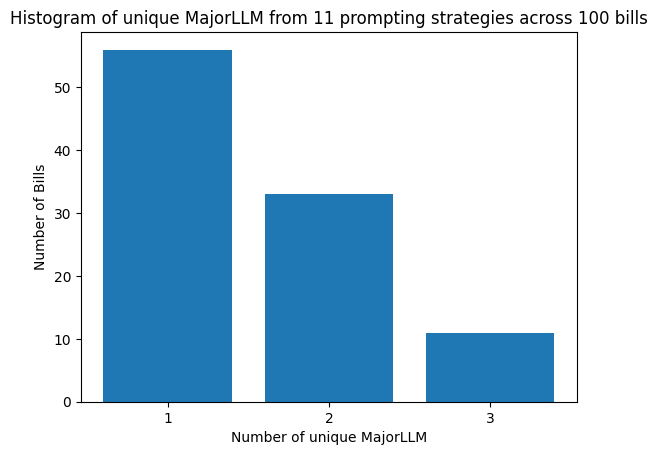

In [196]:
labels, counts = np.unique(unique_MajorLLM["unique_count"], return_counts=True)
plt.bar(labels, counts, align='center')
plt.gca().set_xticks(labels)
plt.title('Histogram of unique MajorLLM from 11 prompting strategies across 100 bills')
plt.xlabel('Number of unique MajorLLM')
plt.ylabel('Number of Bills')
plt.show()